# Diffusion Maps

### PCA vs. Diffusion Maps

The **Swiss Roll** is a classic example of a nonlinear dataset: it's a 2D surface curled in 3D space.

* **PCA** is a linear method. It flattens the data based on global variance but can't capture curved structure.
* **Diffusion Maps** use local relationships and random walks to learn the shape of the data from the inside out.

In this section, we'll compare PCA and diffusion maps on the Swiss Roll to show how each method represents the data — and why diffusion maps are better for nonlinear manifolds.


(10000, 3)


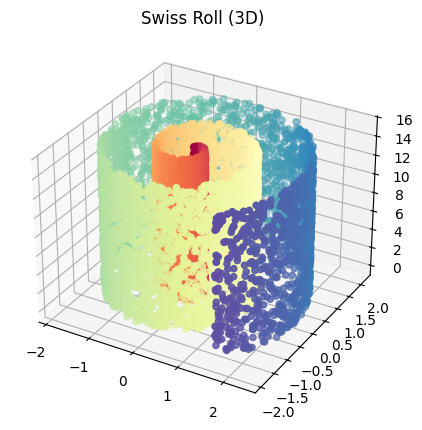

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# set parameters
length_phi = 15   #length of swiss roll in angular direction
length_Z = 15     #length of swiss roll in z direction
sigma = 0.1       #noise strength
m = 10000         #number of samples

# create dataset
phi = length_phi*np.random.rand(m)
xi = np.random.rand(m)
Z = length_Z*np.random.rand(m)
X = 1./6*(phi + sigma*xi)*np.sin(phi)
Y = 1./6*(phi + sigma*xi)*np.cos(phi)

swiss_roll = np.array([X, Y, Z]).transpose()

# check that we have the right shape
print(swiss_roll.shape)

# 3D plot
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(swiss_roll[:, 0], swiss_roll[:, 1], swiss_roll[:, 2], c=phi, cmap=plt.cm.Spectral)
ax.set_title("Swiss Roll (3D)")
plt.show()



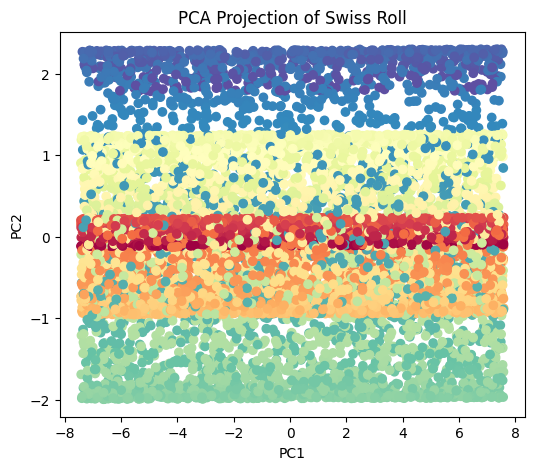

In [3]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(swiss_roll)

# Plot PCA result
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=phi, cmap=plt.cm.Spectral)
plt.title("PCA Projection of Swiss Roll")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [4]:
# !pip install pydiffmap

In [5]:
from pydiffmap import diffusion_map as dm

# initialize Diffusion map object.
neighbor_params = {'n_jobs': -1, 'algorithm': 'ball_tree'}

mydmap = dm.DiffusionMap.from_sklearn(n_evecs=2, k=200, epsilon='bgh', alpha=1.0, neighbor_params=neighbor_params)
# fit to data and return the diffusion map.
dmap = mydmap.fit_transform(swiss_roll)

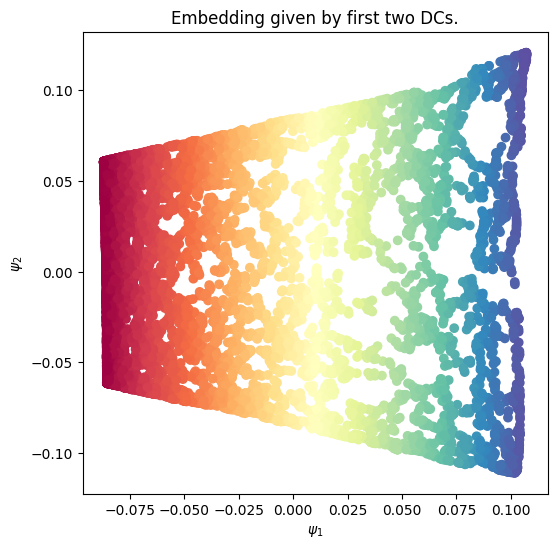

In [6]:
from pydiffmap.visualization import embedding_plot, data_plot

embedding_plot(mydmap, scatter_kwargs = {'c': dmap[:,0], 'cmap': 'Spectral'})
# data_plot(mydmap, dim=3, scatter_kwargs = {'cmap': 'Spectral'})

plt.show()

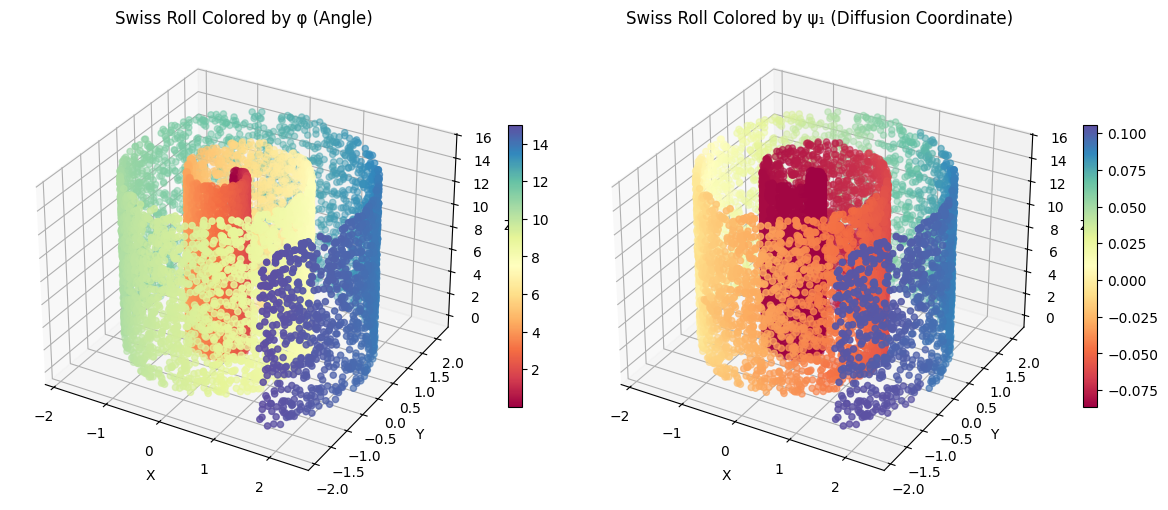

In [241]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 5))

# Left: Swiss Roll colored by φ (original angular coordinate)
ax1 = fig.add_subplot(121, projection='3d')
p1 = ax1.scatter(swiss_roll[:, 0], swiss_roll[:, 1], swiss_roll[:, 2],
                 c=phi, cmap='Spectral')
ax1.set_title("Swiss Roll Colored by φ (Angle)")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")
fig.colorbar(p1, ax=ax1, shrink=0.6)

# Right: Swiss Roll colored by ψ₁ (first diffusion coordinate)
ax2 = fig.add_subplot(122, projection='3d')
p2 = ax2.scatter(swiss_roll[:, 0], swiss_roll[:, 1], swiss_roll[:, 2],
                 c=dmap[:, 0], cmap='Spectral')
ax2.set_title("Swiss Roll Colored by ψ₁ (Diffusion Coordinate)")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")
fig.colorbar(p2, ax=ax2, shrink=0.6)

plt.tight_layout()
plt.show()


### The Gaussian Kernel

The **Gaussian kernel** is a similarity function that transforms distances into values between 0 and 1:

$$
K_{ij} = \exp\left(-\frac{D_{ij}^2}{\epsilon}\right)
$$

Where:

* $D_{ij}$ is the Euclidean distance between points $i$ and $j$
* $\epsilon$ (epsilon) controls the width of the kernel — it determines how quickly similarity decays with distance

---

### Interpretation

* $K_{ij} = 1$: points are identical (zero distance)
* $K_{ij} \approx 0$: points are very far apart
* The kernel assigns **high similarity to close points** and **low similarity to distant ones**, with a smooth decay

---

### Role in Diffusion Maps

The Gaussian kernel defines how strongly each point is connected to every other point. It's the first step in building a graph that reflects the data’s **local geometry**, which is critical for capturing nonlinear structure.


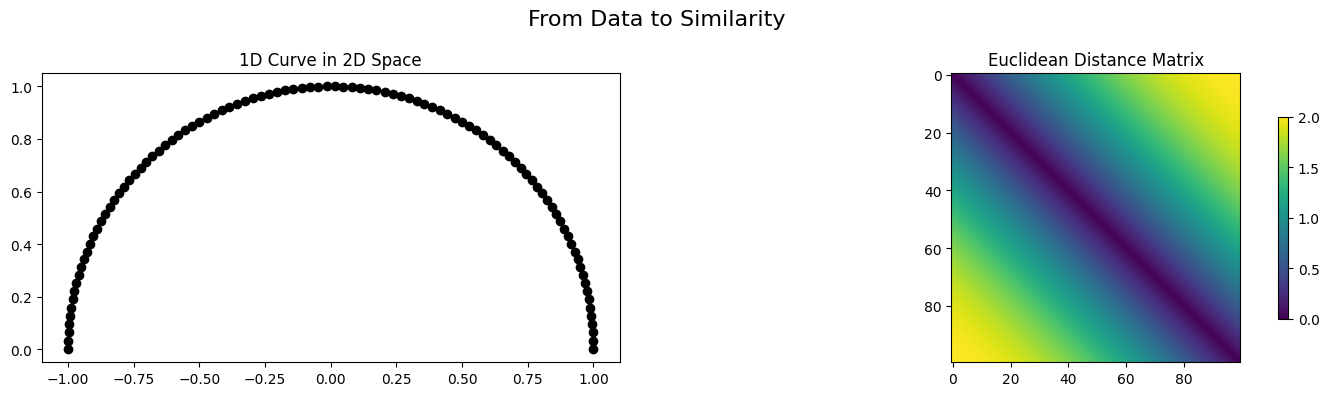

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances

# Create curved data: a half-circle in 2D
theta = np.linspace(0, np.pi, 100)
X = np.stack((np.cos(theta), np.sin(theta)), axis=1)

# Compute pairwise distances and similarities
D = euclidean_distances(X)
epsilon = 0.1
K = np.exp(-D**2 / epsilon)

# Plot data and matrices
fig = plt.figure(figsize=(15, 4))

# 1. Show data points
ax0 = fig.add_subplot(1, 2, 1)
ax0.plot(X[:, 0], X[:, 1], 'o-', c='black')
ax0.set_aspect('equal')
ax0.set_title("1D Curve in 2D Space")

# 2. Distance matrix
ax1 = fig.add_subplot(1, 2, 2)
im1 = ax1.imshow(D, cmap='viridis')
ax1.set_title("Euclidean Distance Matrix")
fig.colorbar(im1, ax=ax1, shrink=0.7)

# 3. Similarity matrix
# ax2 = fig.add_subplot(1, 3, 3)
# im2 = ax2.imshow(K, cmap='hot')
# ax2.set_title("Gaussian Kernel Similarity Matrix")
# fig.colorbar(im2, ax=ax2, shrink=0.7)

plt.suptitle("From Data to Similarity", fontsize=16)
plt.tight_layout()
plt.show()


### Example 1: From Distance to Similarity on a Curved Dataset

In this example, we explore how raw distances between points can be misleading when working with curved data — and how the Gaussian kernel transforms those distances into **local similarities**.

* **Left**: The input data is a tightly curved 1D shape in 2D space.
* **Middle**: The Euclidean distance matrix shows straight-line distances between points. Notice that even nearby neighbors on the curve may appear far apart in this matrix.
* **Right**: The Gaussian kernel transforms these distances into similarity values. Nearby points get values close to 1, while distant points fade to 0. This highlights **local structure** — a key idea in diffusion maps.

Try adjusting `epsilon` to see how it affects the similarity matrix:

* Smaller values make the kernel more **local** (sharp transitions)
* Larger values make it more **global** (smoother transitions)



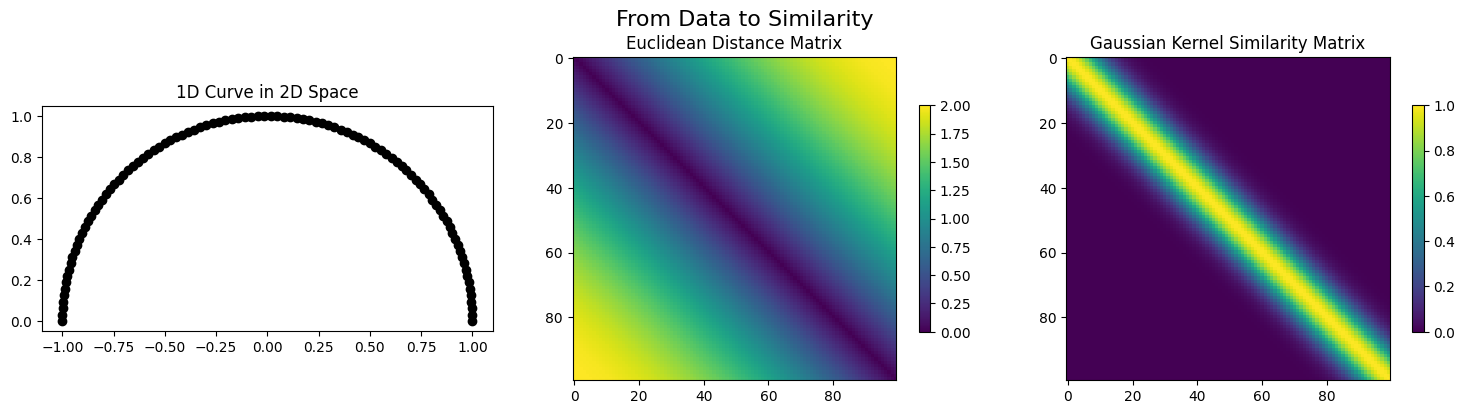

In [10]:
# Calculate and plot the Gaussian kernel similarity matrix
epsilon = .1
K = np.exp(-D**2 / epsilon)

# Plot data and matrices
fig = plt.figure(figsize=(15, 4))

# 1. Show data points
ax0 = fig.add_subplot(1, 3, 1)
ax0.plot(X[:, 0], X[:, 1], 'o-', c='black')
ax0.set_aspect('equal')
ax0.set_title("1D Curve in 2D Space")

# 2. Distance matrix
ax1 = fig.add_subplot(1, 3, 2)
im1 = ax1.imshow(D, cmap='viridis')
ax1.set_title("Euclidean Distance Matrix")
fig.colorbar(im1, ax=ax1, shrink=0.7)

# 3. Similarity matrix
ax2 = fig.add_subplot(1, 3, 3)
im2 = ax2.imshow(K, cmap='viridis')
ax2.set_title("Gaussian Kernel Similarity Matrix")
fig.colorbar(im2, ax=ax2, shrink=0.7)

plt.suptitle("From Data to Similarity", fontsize=16)
plt.tight_layout()
plt.show()

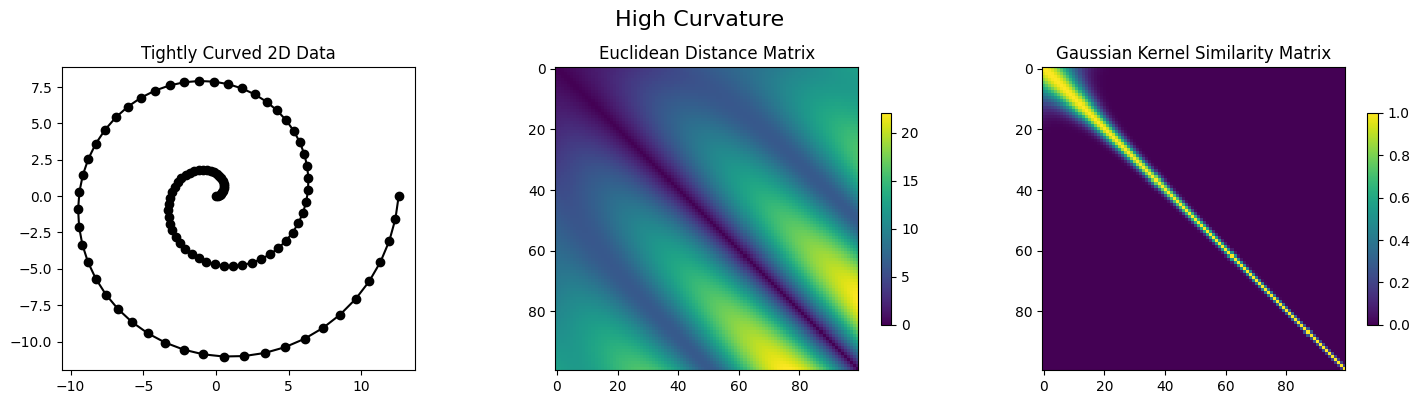

In [13]:
# Create a steeper sine wave (high frequency)
# Create a 2D spiral
t = np.linspace(0, 4 * np.pi, 100)
r = t
X = np.stack((r * np.cos(t), r * np.sin(t)), axis=1)

# Calculate distances and similarities
D = euclidean_distances(X)
# epsilon = np.sqrt(72)
epsilon = 1.5
K = np.exp(-D**2 / epsilon)

# Plot
fig = plt.figure(figsize=(15, 4))

# 1. Data
ax0 = fig.add_subplot(1, 3, 1)
ax0.plot(X[:, 0], X[:, 1], 'o-', c='black')
ax0.set_aspect('equal')
ax0.set_title("Tightly Curved 2D Data")

# 2. Distance matrix
ax1 = fig.add_subplot(1, 3, 2)
im1 = ax1.imshow(D, cmap='viridis')
ax1.set_title("Euclidean Distance Matrix")
fig.colorbar(im1, ax=ax1, shrink=0.7)

# 3. Similarity matrix
ax2 = fig.add_subplot(1, 3, 3)
im2 = ax2.imshow(K, cmap='viridis')
ax2.set_title("Gaussian Kernel Similarity Matrix")
fig.colorbar(im2, ax=ax2, shrink=0.7)

plt.suptitle("High Curvature", fontsize=16)
plt.tight_layout()
plt.show()


### What is a Markov Chain?

A **Markov chain** is a mathematical system that experiences transitions from one state to another, **step by step**, according to **fixed probabilities**.

It’s called "Markov" because it follows the **Markov property**:

> The future state depends *only* on the current state — not how it got there.

In other words, **no memory**.

---

### Key Concepts

* **State**: A possible condition or position in the system (e.g. point A, B, or C).
* **Transition**: The movement from one state to another.
* **Transition probability**: The chance of moving from one state to another. These are typically organized in a **transition matrix**.
* **Transition matrix (P)**: A square matrix where each entry $P_{ij}$ represents the probability of moving from state $i$ to state $j$.



### Example: Simple Weather Model

Let’s say the weather can be **Sunny**, **Cloudy**, or **Rainy**. If it’s sunny today, maybe there’s a 60% chance it’ll stay sunny tomorrow, 30% chance it turns cloudy, and 10% chance of rain. That’s a Markov chain!

| From \ To | Sunny | Cloudy | Rainy |
| --------- | ----- | ------ | ----- |
| Sunny     | 0.6   | 0.3    | 0.1   |
| Cloudy    | 0.3   | 0.4    | 0.3   |
| Rainy     | 0.2   | 0.4    | 0.4   |

Each row adds up to 1.0 — representing total probability from one state.

### Build the Weather Transition Matrix

You're modeling a simple weather system with three possible states:

* **Sunny**
* **Cloudy**
* **Rainy**

You’re told the following rules:

* If it's **Sunny** today:

  * 60% chance it stays **Sunny**
  * 30% chance it becomes **Cloudy**
  * 10% chance it becomes **Rainy**

* If it's **Cloudy** today:

  * 30% chance it becomes **Sunny**
  * 40% chance it stays **Cloudy**
  * 30% chance it becomes **Rainy**

* If it's **Rainy** today:

  * 20% chance it becomes **Sunny**
  * 40% chance it becomes **Cloudy**
  * 40% chance it stays **Rainy**

---

### Your Task:

1. Define the list of states.
2. Build the **transition matrix** using Python, where `P[i][j]` gives the probability of going **from state i to state j**.
3. Verify that each row sums to 1.0.

### Expected Output

```
Row 0 (Sunny): sum = 1.0
Row 1 (Cloudy): sum = 1.0
Row 2 (Rainy): sum = 1.0
```


In [ ]:
states = ["Sunny", "Cloudy", "Rainy"]

# TODO: Fill in the transition matrix based on the rules above
P = [
    # From Sunny: [to Sunny, to Cloudy, to Rainy]
    [       ,       ,       ],

    # From Cloudy: [to Sunny, to Cloudy, to Rainy]
    [       ,       ,       ],

    # From Rainy: [to Sunny, to Cloudy, to Rainy]
    [       ,       ,       ]
]

# Check that each row sums to 1
for i, row in enumerate(P):
    total = sum(row)
    print(f"Row {i} ({states[i]}): sum = {total}")


In diffusion maps, we interpret our data as a **graph** where nodes are data points and edges are weighted by similarity (like our Gaussian kernel). We normalize this graph to form a **Markov transition matrix**.

This lets us simulate a **random walk** through the data — uncovering its structure by observing how the walk flows over time.

### From Similarity to Random Walks

This is where we build the **graph structure** used in diffusion maps:

* Start with the similarity matrix (from the Gaussian kernel)
* Normalize it to form a **Markov transition matrix**
* This matrix represents a **random walk** on the data graph

1. **Affinity matrix**
   The similarity matrix $K$ we built earlier — represents edge weights between points in a graph.

2. **Degree matrix**
   Diagonal matrix $D$ where $D_{ii} = \sum_j K_{ij}$ — total connection strength of each point.

3. **Markov matrix / transition matrix $P$**
   Row-normalized affinity matrix:

   $$
   P_{ij} = \frac{K_{ij}}{\sum_j K_{ij}} = D^{-1}K
   $$

   Interpreted as **transition probabilities** — how likely a random walk moves from point $i$ to $j$.


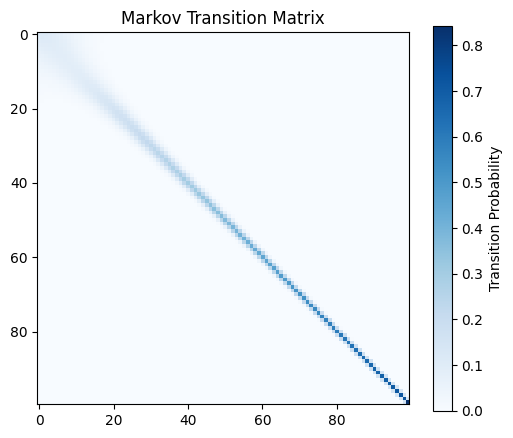

In [271]:
# From previous section: K is the Gaussian kernel similarity matrix
# Step 1: Compute degree matrix (sum of each row)
degree = np.sum(K, axis=1)

# Step 2: Row-normalize to create Markov transition matrix
P = K / degree[:, np.newaxis]

# Optional: visualize the transition matrix
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.imshow(P, cmap='Blues')
plt.title("Markov Transition Matrix")
plt.colorbar(label="Transition Probability")
plt.show()


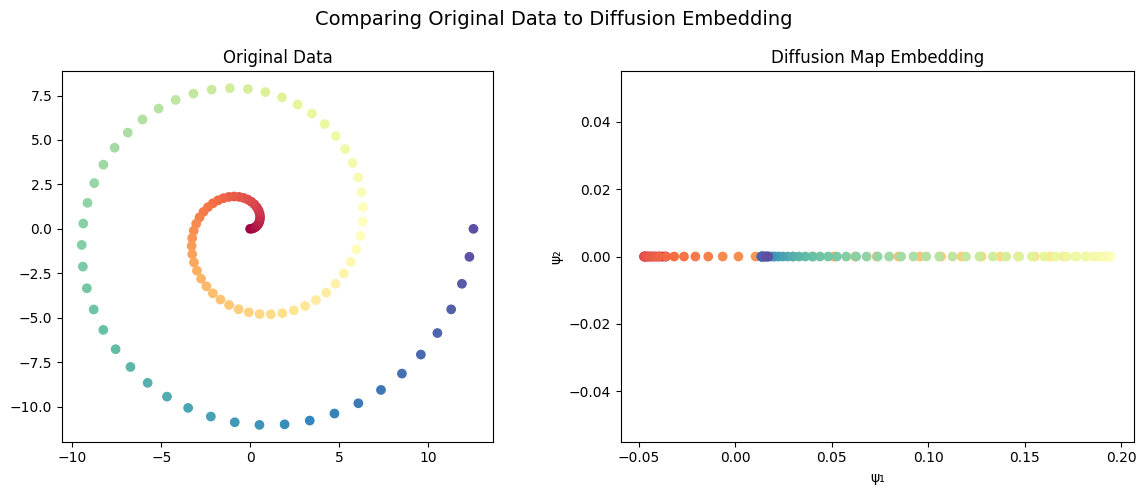

In [272]:
from scipy.linalg import eigh  # since P is symmetric after normalization

# Step 1: Compute eigenvalues and eigenvectors
eigvals, eigvecs = eigh(P)

# Step 2: Sort eigenvalues/vectors in descending order
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# Step 3: Take top 2 nontrivial eigenvectors (skip eigvec[:, 0])
psi1 = eigvecs[:, 1] * eigvals[1]
psi2 = eigvecs[:, 2] * eigvals[2]

# Step 4: Plot the diffusion embedding
import matplotlib.pyplot as plt

# Assume you already have:
# X      - original data (N x 2)
# psi1   - first nontrivial diffusion coordinate
# psi2   - second nontrivial diffusion coordinate

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot original data
axes[0].scatter(X[:, 0], X[:, 1], c=np.arange(len(X)), cmap='Spectral')
axes[0].set_title("Original Data")
axes[0].set_aspect('equal')

# Plot diffusion map embedding
axes[1].scatter(psi1, np.zeros_like(psi1), c=np.arange(len(psi1)), cmap='Spectral')
axes[1].set_title("Diffusion Map Embedding")
axes[1].set_xlabel("ψ₁")
axes[1].set_ylabel("ψ₂")

plt.suptitle("Comparing Original Data to Diffusion Embedding", fontsize=14)
plt.tight_layout()
plt.show()


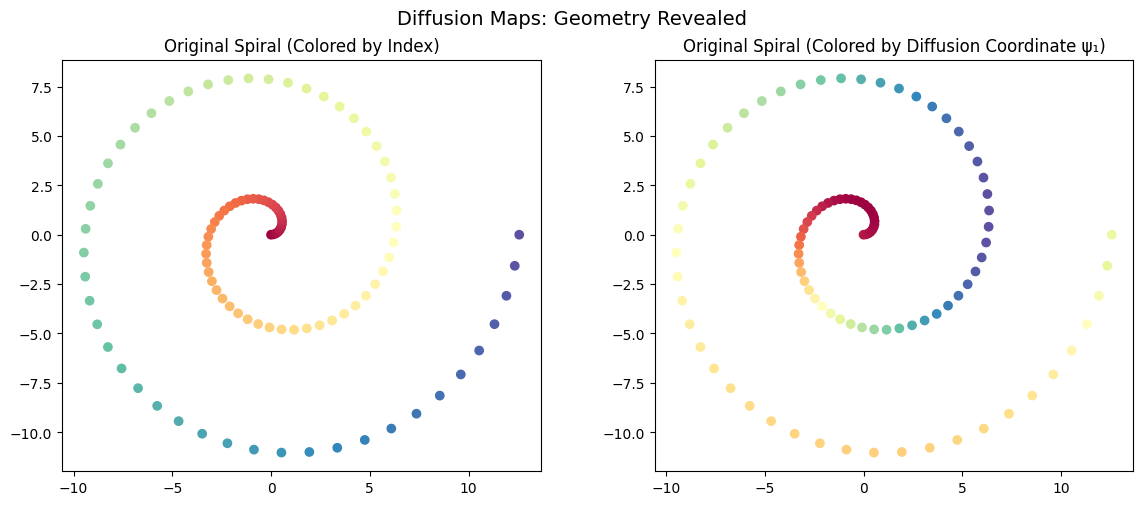

In [323]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.linalg import eigh

# Create spiral data
t = np.linspace(0, 4 * np.pi, 100)
r = t
X = np.stack((r * np.cos(t), r * np.sin(t)), axis=1)

# Compute distance matrix
D = squareform(pdist(X))

# Choose epsilon (you can optimize this)
# epsilon = np.median(D)**2
epsilon = 1.70

# Compute Gaussian kernel
K = np.exp(-D**2 / epsilon)

# Row-normalize to get Markov matrix P
row_sums = K.sum(axis=1, keepdims=True)
P = K / row_sums

# Compute eigenvalues and eigenvectors
eigvals, eigvecs = eigh(P)

# Sort in descending order
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# First nontrivial diffusion coordinate
psi1 = eigvecs[:, 1] * eigvals[1]

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Original Data (colored by index)
axes[0].scatter(X[:, 0], X[:, 1], c=np.arange(len(X)), cmap='Spectral')
axes[0].set_title("Original Spiral (Colored by Index)")
axes[0].set_aspect('equal')

# 2. Original Data (colored by diffusion coordinate ψ₁)
axes[1].scatter(X[:, 0], X[:, 1], c=psi1, cmap='Spectral')
axes[1].set_title("Original Spiral (Colored by Diffusion Coordinate ψ₁)")
axes[1].set_aspect('equal')

plt.suptitle("Diffusion Maps: Geometry Revealed", fontsize=14)
plt.tight_layout()
plt.show()


72.32286496253687


Text(0, 0.5, 'log(distance)')

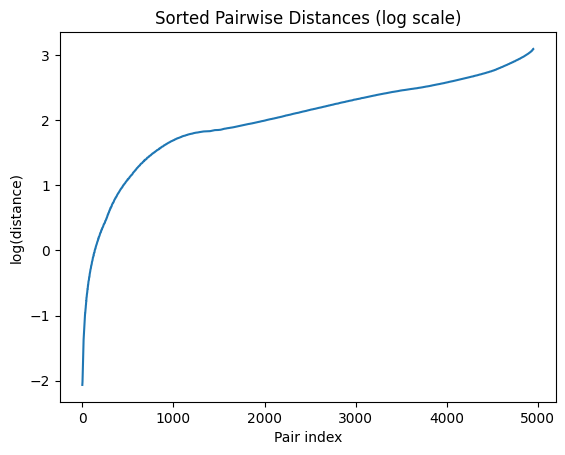

In [291]:
from scipy.spatial.distance import pdist, squareform
D = squareform(pdist(X))
epsilon = np.median(D)**2
print(epsilon)

dists = D[np.triu_indices_from(D, k=1)]
plt.plot(np.log(np.sort(dists)))
plt.title("Sorted Pairwise Distances (log scale)")
plt.xlabel("Pair index")
plt.ylabel("log(distance)")



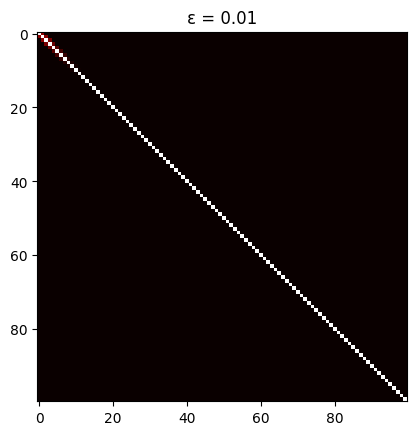

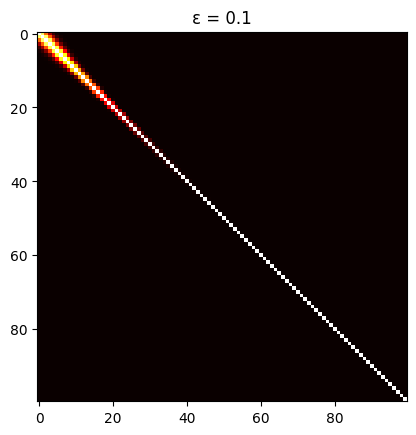

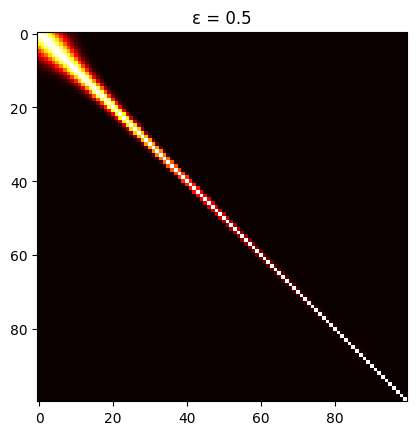

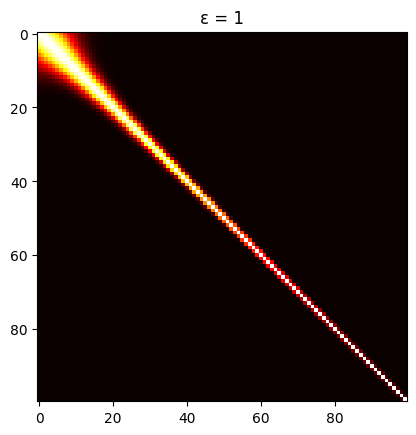

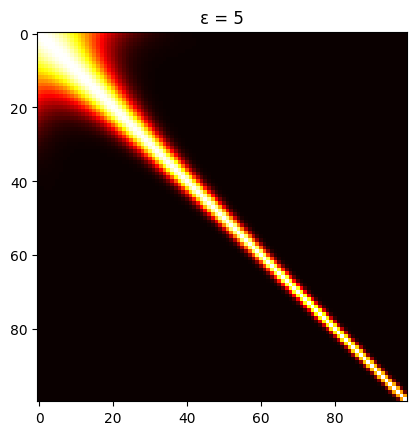

In [307]:
epsilons = [0.01, 0.1, 0.5, 1, 5]
for eps in epsilons:
    K = np.exp(-D**2 / eps)
    plt.imshow(K, cmap='hot')
    plt.title(f"ε = {eps}")
    plt.show()



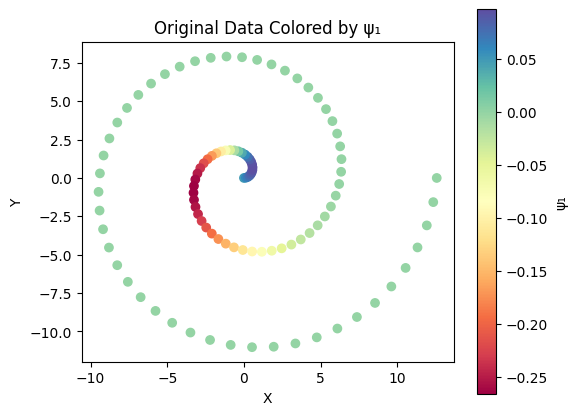

In [42]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=psi1, cmap='Spectral')
plt.title("Original Data Colored by ψ₁")
plt.xlabel("X")
plt.ylabel("Y")
plt.gca().set_aspect('equal')
plt.colorbar(label='ψ₁')
plt.show()


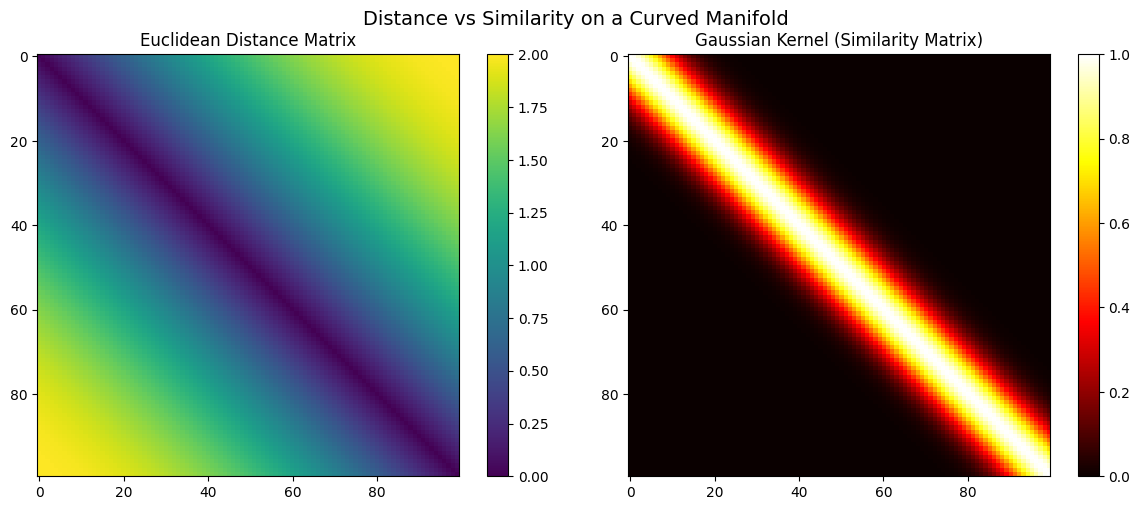

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances

# Create curved data: a half circle
theta = np.linspace(0, np.pi, 100)
X = np.stack((np.cos(theta), np.sin(theta)), axis=1)  # shape (100, 2)

# Compute pairwise Euclidean distances
D = euclidean_distances(X)

# Apply Gaussian kernel to convert distances to similarities
epsilon = 0.1  # kernel bandwidth
K = np.exp(-D**2 / epsilon)

# Visualize both
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

im1 = ax1.imshow(D, cmap='viridis')
ax1.set_title("Euclidean Distance Matrix")
fig.colorbar(im1, ax=ax1)

im2 = ax2.imshow(K, cmap='hot')
ax2.set_title("Gaussian Kernel (Similarity Matrix)")
fig.colorbar(im2, ax=ax2)

plt.suptitle("Distance vs Similarity on a Curved Manifold", fontsize=14)
plt.tight_layout()
plt.show()


In [16]:
# !pip install pydiffmap